# 🚨 Vendor Invoice Risk Flagging & Anomaly Classification

## Overview
This notebook builds an end-to-end Machine Learning classification pipeline to detect suspicious, risky, or abnormal vendor invoices that require **manual finance approval**. By cross-referencing line-item purchase orders with vendor invoice records, we identify discrepancies in dollar amounts and abnormal receiving delays, perform statistical hypothesis testing to find significant risk indicators, and train optimized classifiers (Logistic Regression, Decision Trees, and tuned Random Forest) to automate risk detection.

---

## 🗄️ Database & Tables Referenced
- **Database File**: `inventory.db` (SQLite)
- **Tables Referenced**:
  1. **`purchases`**: Item-level purchase order transactions.
     - Extracted columns: `PONumber`, `Brand`, `Quantity`, `Dollars`, `PODate`, `ReceivingDate`
  2. **`vendor_invoice`**: Invoices submitted by vendors.
     - Extracted columns: `PONumber`, `Quantity`, `Dollars`, `Freight`, `PODate`, `InvoiceDate`, `PayDate`
  3. **`sqlite_master`**: Queried for database schema inspection.

---

## 📊 Extracted & Engineered Features
| Feature Name | Source Table | Extraction / Aggregation Logic | Description |
| :--- | :--- | :--- | :--- |
| `PONumber` | `purchases`, `vendor_invoice` | Join key | Purchase Order identifier |
| `invoice_quantity` | `vendor_invoice` | `vi.Quantity` | Total physical units billed on invoice |
| `invoice_dollars` | `vendor_invoice` | `vi.Dollars` | Total dollar amount billed on invoice |
| `Freight` | `vendor_invoice` | `vi.Freight` | Freight/shipping charge |
| `days_po_to_invoice` | `vendor_invoice` | `julianday(InvoiceDate) - julianday(PODate)` | Days elapsed from PO creation to invoice |
| `days_to_pay` | `vendor_invoice` | `julianday(PayDate) - julianday(InvoiceDate)` | Days elapsed from invoice to payment |
| `total_brands` | `purchases` | `COUNT(DISTINCT p.Brand)` | Distinct brands included in the PO |
| `total_item_quantity`| `purchases` | `SUM(p.Quantity)` | Sum of all ordered item quantities |
| `total_item_dollars` | `purchases` | `SUM(p.Dollars)` | Sum of all item purchase amounts |
| `avg_receiving_delay`| `purchases` | `AVG(julianday(ReceivingDate) - julianday(PODate))` | Mean days taken to receive items |
| `flag_invoice` | *Engineered Target* | Discrepancy rule ($|\Delta| > \$5$ or delay $> 10$ days) | **Target Variable** (1 = Risk/Flagged, 0 = Normal) |

---

## 🔄 Workflow Steps
1. **Dependency Imports & Database Connection**: Connect to SQLite database and list tables.
2. **Data Aggregation & SQL Joins**: Aggregate line items in `purchases` and join with `vendor_invoice` using a Common Table Expression (CTE).
3. **Risk Label Creation**: Define business logic rule to generate ground-truth labels (`flag_invoice`).
4. **Exploratory Analysis & Correlation**: Analyze class distribution and feature correlation heatmap.
5. **Statistical Significance Testing**: Run two-sample Welch's t-tests to identify features with statistically significant divergence between flagged and normal invoices (p < 0.05).
6. **Data Preprocessing & Scaling**: Stratified train/test split (80/20) and standardize features via `StandardScaler`.
7. **Baseline Model Benchmarking**: Train and compare Logistic Regression, Decision Tree, and Random Forest.
8. **Feature Importance & Selection**: Analyze Random Forest feature importances and retain top predictive features.
9. **Hyperparameter Optimization**: Use `GridSearchCV` with 5-fold cross-validation optimizing for `f1_score`.
10. **Final Evaluation**: Confusion matrix analysis and final parameter validation.



### Step 1: Import Dependencies
Imports required libraries for data processing (`pandas`, `numpy`), database connection (`sqlite3`), statistical testing (`scipy.stats.ttest_ind`), visualization (`seaborn`, `matplotlib`), scaling (`StandardScaler`, `MinMaxScaler`), model training (`LogisticRegression`, `DecisionTreeClassifier`, `RandomForestClassifier`), hyperparameter search (`GridSearchCV`), and evaluation metrics (`f1_score`, `confusion_matrix`, etc.).


In [33]:
import pandas as pd
import sqlite3
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import ttest_ind
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

### Step 2: Connect to SQLite Database & List Tables
- **Database**: `inventory.db`
- **Table Referenced**: `sqlite_master`
- **Columns Extracted**: `name` (table names)
- **Description**: Connects to the SQLite database and queries the master schema to list all existing tables.


In [34]:
conn = sqlite3.connect(r'D:\PROJECTS\INVOICE\data\inventory.db')

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

print(tables)

              name
0        purchases
1  purchase_prices
2   vendor_invoice
3  begin_inventory
4    end_inventory


### Step 3: Preview First 5 Records of All Tables
- **Tables Queried**: `purchases`, `purchase_prices`, `vendor_invoice`, `begin_inventory`, `end_inventory`
- **Description**: Iterates through each database table and prints sample rows to inspect table schemas and data types.


In [35]:
for table in tables['name']:
    print(f"Table: {table}")
    df = pd.read_sql_query(f'SELECT * FROM {table} limit 5', conn)
    display(df)

Table: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


### Step 4: Aggregate Purchase Order Line Items
- **Table Referenced**: `purchases`
- **Columns Extracted & Aggregated**:
  - `PONumber`: Purchase order identifier (grouping key).
  - `Brand`: `COUNT(DISTINCT Brand)` as `total_brands` (number of distinct brands).
  - `Quantity`: `SUM(Quantity)` as `total_quantity` (total units ordered).
  - `Dollars`: `SUM(Dollars)` as `total_item_dollars` (total purchase order amount).
  - `ReceivingDate`, `PODate`: `AVG(julianday(ReceivingDate) - julianday(PODate))` as `avg_days_to_receive` (average delivery delay in days).
- **Description**: Aggregates line items to PO-level metrics.


In [36]:
purchase_agg_df=pd.read_sql_query("""
    select
    p.PONumber,
    count(distinct p.Brand) as total_brands,
    sum(p.Quantity) as total_quantity,
    sum(p.Dollars) as total_item_dollars,
    avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_days_to_receive
    from purchases p
    group by p.PONumber
    """, conn
)

### Step 5: Extract Vendor Invoice Metrics and Date Latencies
- **Table Referenced**: `vendor_invoice`
- **Columns Extracted & Derived**:
  - `PONumber`: Purchase order number.
  - `Quantity` as `invoice_quantity`: Quantity billed on invoice.
  - `Dollars` as `invoice_dollars`: Dollar amount billed on invoice.
  - `Freight`: Shipping/freight charge.
  - `InvoiceDate`, `PODate`: `(julianday(InvoiceDate) - julianday(PODate))` as `days_po_to_invoice` (latency between PO creation and invoice date).
  - `PayDate`, `InvoiceDate`: `(julianday(PayDate) - julianday(InvoiceDate))` as `days_to_pay` (latency between invoice date and payment date).
- **Description**: Computes invoice-level cycle times and financial figures.


In [37]:
pd.read_sql_query("""
select
vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.POdate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
from vendor_invoice vi
""", conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


### Step 6: Unified CTE Query - Merge Purchases with Vendor Invoices
- **Tables Referenced**: `purchases` (pa) and `vendor_invoice` (vi)
- **Join Type**: `LEFT JOIN` on `vi.PONumber = pa.PONumber`
- **Columns Extracted**:
  - `vi.PONumber`: PO number
  - `vi.Quantity` -> `invoice_quantity`
  - `vi.Dollars` -> `invoice_dollars`
  - `vi.Freight` -> `Freight`
  - `days_po_to_invoice`: Cycle time from PO to Invoice
  - `days_to_pay`: Cycle time from Invoice to Payment
  - `pa.total_brands`: Total distinct brands from purchases
  - `pa.total_item_quantity`: Total item quantity from purchases
  - `pa.total_item_dollars`: Total dollar amount from purchases
  - `pa.avg_receiving_delay`: Average receiving delay in days
- **Description**: Creates the comprehensive dataset `combined_df` combining invoice headers and PO line aggregations.


In [38]:
combined_df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay

FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber
""", conn)

### Step 7: Inspect Combined Dataset
Displays `combined_df` to inspect the unified records, feature values, and schema consistency.


In [39]:
combined_df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


### Step 8: Label Engineering - Create Ground Truth Risk Flag (`flag_invoice`)
- **Columns Used**: `invoice_dollars`, `total_item_dollars`, `avg_receiving_delay`
- **Business Logic**:
  - **Flag = 1 (Risk / Manual Review Needed)** if:
    1. Dollar discrepancy: `abs(invoice_dollars - total_item_dollars) > 5`
    2. Receiving delay: `avg_receiving_delay > 10 days`
  - **Flag = 0 (Normal / Safe)** otherwise.
- **Description**: Generates the binary target label `flag_invoice` and prints the class distribution counts.


In [40]:
def create_invoice_risk_label(row):

    # Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1

    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    return 0


combined_df["flag_invoice"] = combined_df.apply(create_invoice_risk_label, axis=1)

combined_df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

### Step 9: Visualize Risk Flag Class Distribution
- **Column Plotted**: `flag_invoice`
- **Description**: Plots a bar chart displaying the frequency of safe (0) vs flagged (1) invoices to evaluate class imbalance.


<Axes: title={'center': 'Invoice Risk Flag Distribution'}, xlabel='flag_invoice'>

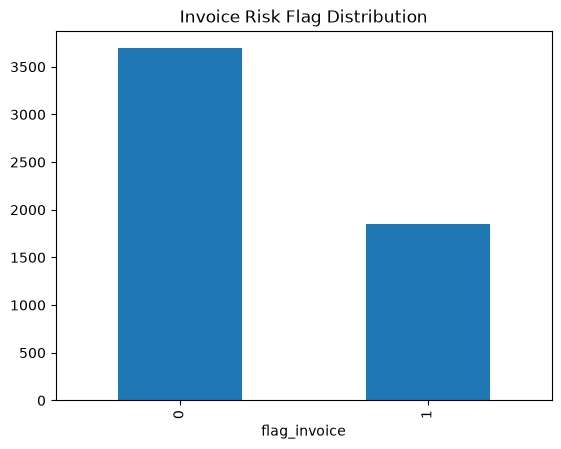

In [41]:
combined_df["flag_invoice"].value_counts().plot(kind='bar', title='Invoice Risk Flag Distribution')

### Step 10: Correlation Heatmap of Numeric Features
- **DataFrame**: `combined_df`
- **Description**: Computes and plots the Pearson correlation matrix across all numeric features to assess feature relationships and collinearity.


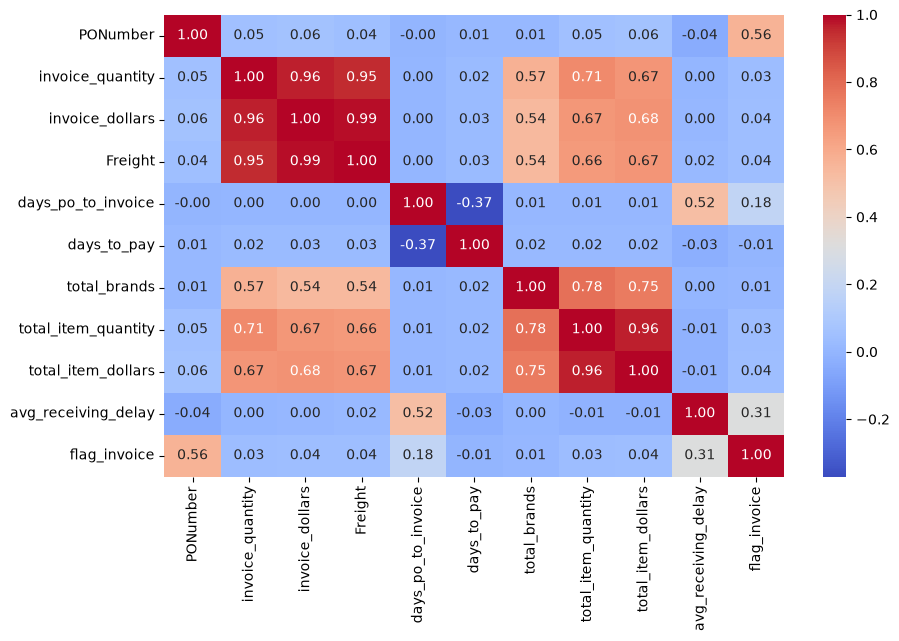

In [42]:
plt.figure(figsize=(10, 6))
sns.heatmap(combined_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()


### Step 11: Partition Dataset into Flagged and Normal Subsets
- **Column Used**: `flag_invoice`
- **Description**: Subsets `combined_df` into `flagged` (flag == 1) and `normal` (flag == 0) groups for subsequent statistical hypothesis testing.


In [43]:
flagged= combined_df[combined_df["flag_invoice"] == 1]
normal= combined_df[combined_df["flag_invoice"] == 0]


### Step 12: Initialize Feature Significance Testing Containers
- **Description**: Initializes tracking lists (`significant_features`, `non_significant_features`, `results`) to store results from statistical tests.


In [44]:
significant_features = []
non_significant_features = []
results = []


### Step 13: Define Candidate Numerical Metrics for Statistical Testing
- **Metrics Listed**: `invoice_quantity`, `invoice_dollars`, `Freight`, `days_po_to_invoice`, `days_to_pay`, `total_brands`, `total_item_quantity`, `total_item_dollars`, `avg_receiving_delay`
- **Description**: Lists all candidate numerical features to test for statistical difference between normal and flagged invoices.


In [45]:

metrics = [
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'days_po_to_invoice',
    'days_to_pay',
    'total_brands',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay'
]

### Step 14: Conduct Two-Sample T-Tests (Welch's T-Test)
- **Method**: `scipy.stats.ttest_ind(equal_var=False)`
- **Significance Level**: alpha = 0.05 (p < 0.05)
- **Description**: Determines which numerical metrics show a statistically significant difference between normal and risky invoices.


In [46]:
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })
    else:
        non_significant_features.append(metric)

### Step 15: Display Statistically Significant Features
Displays the list of features where p < 0.05, indicating strong discriminative power for classification.


In [47]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

### Step 16: Display Non-Significant Features
Displays features where differences between normal and flagged invoices were not statistically significant (p >= 0.05).


In [48]:
non_significant_features

['days_to_pay', 'total_brands']

### Step 17: Select Initial Feature Set (X) and Target Label (y)
- **Features (X)**: `invoice_quantity`, `invoice_dollars`, `Freight`, `total_brands`, `total_item_quantity`, `days_po_to_invoice`, `total_item_dollars`
- **Target (y)**: `flag_invoice`
- **Description**: Isolates candidate predictor variables and the target classification label for model development.


In [49]:
X = combined_df[[
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'total_brands',
    'total_item_quantity',
    'days_po_to_invoice',
    'total_item_dollars'
]]

y = combined_df['flag_invoice']

### Step 18: Stratified Train-Test Split (80% Train, 20% Test)
- **Parameters**: `test_size=0.2`, `random_state=42`, `stratify=y`
- **Description**: Splits data into training and test sets while preserving the proportion of normal vs flagged invoices across both sets.


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Step 19: Feature Normalization with StandardScaler
- **Scaler**: `StandardScaler()` (z-score standardization)
- **Description**: Fits the scaler on `X_train` and transforms both `X_train` and `X_test` to ensure features have zero mean and unit variance.


In [51]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 20: Import Classifier Algorithms
Imports `LogisticRegression`, `DecisionTreeClassifier`, and `RandomForestClassifier` from `sklearn`.


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### Step 21: Train Logistic Regression Classifier (Model 1)
- **Algorithm**: `LogisticRegression(random_state=42)`
- **Description**: Trains a baseline linear classification model on the scaled training features (`X_train_scaled`, `y_train`).


In [53]:

model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

### Step 22: Train Decision Tree Classifier (Model 2)
- **Algorithm**: `DecisionTreeClassifier(random_state=42)`
- **Description**: Trains a non-linear decision tree classifier on the scaled training features.


In [54]:
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### Step 23: Train Random Forest Classifier (Model 3)
- **Algorithm**: `RandomForestClassifier(random_state=42)`
- **Description**: Fits an ensemble of decision trees to increase predictive stability and reduce overfitting.


In [55]:
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### Step 24: Define Classification Performance Evaluation Function
- **Metrics Computed**: Accuracy, Precision, Recall, F1 Score, and complete `classification_report`.
- **Description**: Creates helper function `evaluate_model()` to systematically assess classifier performance on test data.


In [56]:
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score


def evaluate_model(model, features, target, model_name):
    predictions = model.predict(features)

    print(f"{model_name}")
    print(f"Accuracy: {accuracy_score(target, predictions):.3f}")
    print(f"Precision: {precision_score(target, predictions, zero_division=0):.3f}")
    print(f"Recall: {recall_score(target, predictions, zero_division=0):.3f}")
    print(f"F1 Score: {f1_score(target, predictions, zero_division=0):.3f}")
    print(classification_report(target, predictions, zero_division=0))

### Step 25: Benchmark Initial Classification Models
- **Description**: Evaluates Model 1 (Logistic Regression), Model 2 (Decision Tree), and Model 3 (Random Forest) against `(X_test_scaled, y_test)`. Displays precision, recall, and F1 scores.


In [57]:
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')

Logistic Regression
Accuracy: 0.672
Precision: 0.579
Recall: 0.059
F1 Score: 0.108
              precision    recall  f1-score   support

           0       0.68      0.98      0.80       739
           1       0.58      0.06      0.11       370

    accuracy                           0.67      1109
   macro avg       0.63      0.52      0.45      1109
weighted avg       0.64      0.67      0.57      1109

Decision Tree Classifier
Accuracy: 0.819
Precision: 0.735
Recall: 0.714
F1 Score: 0.724
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       739
           1       0.74      0.71      0.72       370

    accuracy                           0.82      1109
   macro avg       0.80      0.79      0.79      1109
weighted avg       0.82      0.82      0.82      1109

Random Forest Classifier
Accuracy: 0.876
Precision: 0.923
Recall: 0.684
F1 Score: 0.786
              precision    recall  f1-score   support

           0       0.86      0.9

### Step 26: Extract Random Forest Feature Importances
- **Model**: `model3` (Random Forest)
- **Description**: Retrieves the Gini importance scores (`feature_importances_`) for each input feature.


In [58]:
model3.feature_importances_

array([0.14247549, 0.15605337, 0.14531062, 0.08294927, 0.17626282,
       0.07634923, 0.2205992 ])

### Step 27: Rank Features by Predictive Importance
- **Description**: Builds and displays a sorted DataFrame of feature importances to identify the primary drivers of invoice risk.


In [59]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
6,total_item_dollars,0.220599
4,total_item_quantity,0.176263
1,invoice_dollars,0.156053
2,Freight,0.145311
0,invoice_quantity,0.142475
3,total_brands,0.082949
5,days_po_to_invoice,0.076349


### Step 28: Refined Feature Selection & Random Forest Retraining
- **Refined Feature Set**: `invoice_quantity`, `invoice_dollars`, `Freight`, `total_item_quantity`, `total_item_dollars` (omitting low-importance features `total_brands` and `days_po_to_invoice`).
- **Description**: Re-splits, re-scales, and retrains Random Forest using the refined 5-feature subset and evaluates test performance.


In [60]:
X = combined_df[[
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'total_item_quantity',
    'total_item_dollars'
]]

y = combined_df['flag_invoice']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

evaluate_model(
    model3,
    X_test_scaled,
    y_test,
    'Random Forest Classifier'
)


Random Forest Classifier
Accuracy: 0.877
Precision: 0.937
Recall: 0.678
F1 Score: 0.787
              precision    recall  f1-score   support

           0       0.86      0.98      0.91       739
           1       0.94      0.68      0.79       370

    accuracy                           0.88      1109
   macro avg       0.90      0.83      0.85      1109
weighted avg       0.88      0.88      0.87      1109



### Step 29: Define Hyperparameter Tuning Grid for Random Forest
- **Parameters Searched**:
  - `n_estimators`: `[100, 200, 300]`
  - `max_depth`: `[None, 4, 5, 6]`
  - `min_samples_split`: `[2, 3, 5]`
  - `min_samples_leaf`: `[1, 2, 5]`
  - `criterion`: `['gini', 'entropy']`
- **Description**: Specifies the search grid for optimizing the Random Forest classifier.


In [61]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

### Step 30: Execute GridSearchCV with 5-Fold Cross-Validation (Optimizing F1 Score)
- **Optimization Metric**: `f1_score` (balances precision and recall for anomaly detection).
- **Cross-Validation**: 5-Fold CV (`cv=5`, `n_jobs=-1`).
- **Description**: Searches parameter combinations to find the optimal estimator configuration and evaluates the best model on test data.


In [62]:

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

evaluate_model(
    grid_search,
    X_test_scaled,
    y_test,
    "Random Forest Classifier"
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Random Forest Classifier
Accuracy: 0.885
Precision: 0.955
Recall: 0.689
F1 Score: 0.801
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       739
           1       0.96      0.69      0.80       370

    accuracy                           0.89      1109
   macro avg       0.91      0.84      0.86      1109
weighted avg       0.89      0.89      0.88      1109



### Step 31: Confusion Matrix Comparison & Best Hyperparameters
- **Description**: Computes and displays confusion matrices for both the tuned GridSearch estimator and baseline Model 3, and prints the optimal hyperparameter settings (`grid_search.best_params_`).


In [63]:
print("Grid Search Confusion Matrix:")
print(confusion_matrix(y_test, grid_search.predict(X_test_scaled)))

print("\nModel 3 Confusion Matrix:")
print(confusion_matrix(y_test, model3.predict(X_test_scaled)))

print("\nBest Parameters:")
print(grid_search.best_params_)


Grid Search Confusion Matrix:
[[727  12]
 [115 255]]

Model 3 Confusion Matrix:
[[722  17]
 [119 251]]

Best Parameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
